# Decision Trees Classification Assignment
## Medina County Career Center — AI/ML

**Your task:** Build a decision tree classification model from scratch using one of the datasets below.

You've seen the full process in the Iris class example. Now it's your turn!

---

### Choose Your Dataset

Pick ONE of these datasets. Each has a different classification target:

| Dataset | How to Load | What You Predict | Rows | Features | Classes | Difficulty |
|---------|-------------|------------------|------|----------|---------|------------|
| **Palmer Penguins** | `sns.load_dataset('penguins')` | Penguin species | 344 | 4 numeric | 3 | Easy |
| **Wine Recognition** | `load_wine(as_frame=True)` | Wine cultivar (vineyard) | 178 | 13 numeric | 3 | Easy-Medium |
| **Breast Cancer Wisconsin** | `load_breast_cancer(as_frame=True)` | Malignant vs Benign | 569 | 30 numeric | 2 | Medium |

See the **Dataset Guide** for full descriptions of each one.

**Note:** Wine and Breast Cancer are built into scikit-learn — no internet needed. Palmer Penguins is in seaborn.

---

### The Steps (follow this structure)

1. Import libraries (no installs needed!)
2. Load your chosen dataset
3. Explore: check shape, columns, missing values, and clean the data
4. Drop any non-numeric columns (if your dataset has them)
5. Make at least ONE scatter plot — pick two features and color by class
6. Train/test split (80/20)
7. Build and train a DecisionTreeClassifier (set max_depth=3 to start)
8. Evaluate: print accuracy and the classification report
9. Show the confusion matrix as a heatmap
10. Visualize the tree using plot_tree
11. Show feature importance as a bar chart
12. Try changing max_depth and compare accuracy

### Quick Reference — Copy and Adapt These Patterns

You don't need to switch back to the example notebook. Here are the code patterns for each step — just change the variable names and values to fit your dataset.

```python
# --- IMPORTS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- LOAD (pick the one that matches your dataset) ---

# Palmer Penguins (from seaborn):
df = sns.load_dataset('penguins')

# Wine Recognition (from sklearn — no internet needed):
from sklearn.datasets import load_wine
wine = load_wine(as_frame=True)
X = wine.data
y = wine.target
df = X.copy()
df['cultivar'] = y

# Breast Cancer Wisconsin (from sklearn — no internet needed):
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer(as_frame=True)
X = cancer.data
y = cancer.target
df = X.copy()
df['diagnosis'] = y

# --- EXPLORE + CLEAN ---
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())
df = df.dropna()

# --- DROP NON-NUMERIC COLUMNS (if needed) ---
df = df.drop(columns=['col1', 'col2'])   # drop text columns

# --- SET UP X AND y ---
X = df.drop('your_target', axis=1)
y = df['your_target']

# --- SCATTER PLOT (color by class) ---
plt.figure(figsize=(8, 6))
for className in y.unique():
    mask = y == className
    plt.scatter(X.loc[mask, 'feature1'], X.loc[mask, 'feature2'],
                label=className, alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Your Title')
plt.legend()
plt.show()

# --- SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# --- BUILD + TRAIN ---
treeModel = DecisionTreeClassifier(max_depth=3, random_state=42)
treeModel.fit(X_train, y_train)

# --- EVALUATE ---
predictions = treeModel.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy: {accuracy:.2%}')
print(classification_report(y_test, predictions))

# --- CONFUSION MATRIX ---
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# --- TREE VISUALIZATION ---
plt.figure(figsize=(16, 8))
plot_tree(treeModel, feature_names=list(X.columns),
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree')
plt.show()

# --- FEATURE IMPORTANCE ---
importanceDf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': treeModel.feature_importances_
}).sort_values('Importance', ascending=False)
plt.barh(importanceDf['Feature'], importanceDf['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()

# --- EXPERIMENT WITH DEPTH ---
for depth in [2, 3, 5, 10, None]:
    m = DecisionTreeClassifier(max_depth=depth, random_state=42)
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    print(f'max_depth={depth}: accuracy={acc:.2%}')
```

## Step 1: Install + Import Libraries

In [1]:
# No extra installs needed!
# Palmer Penguins is in seaborn, Wine and Breast Cancer are in sklearn
print("All datasets are built-in — no pip install needed!")

All datasets are built-in — no pip install needed!


In [3]:
# Import your libraries here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## Step 2: Load Your Dataset

**Palmer Penguins:** `sns.load_dataset('penguins')`

**Wine Recognition:** `from sklearn.datasets import load_wine` then `wine = load_wine(as_frame=True)`

**Breast Cancer:** `from sklearn.datasets import load_breast_cancer` then `cancer = load_breast_cancer(as_frame=True)`

In [4]:
# Load your chosen dataset
df = sns.load_dataset('penguins')

## Step 3: Explore the Data

Print the shape, column names, first few rows, and check for missing values. If there are missing values, drop them.

In [5]:
# Explore your data here
# - How many rows and columns?
# - What are the column names?
# - Any missing values? If so, drop them.
# - How many samples per class? (value_counts)
print("Shape of dataset:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values per column:\n", df.isnull().sum())

# Drop missing values
df = df.dropna()

print("\nSamples per class:\n", df['species'].value_counts())

Shape of dataset: (344, 7)

Columns: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

Missing values per column:
 species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Samples per class:
 species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


## Step 4: Clean the Data

Drop any non-numeric columns (text columns like 'island', 'sex', etc.) since the tree can't use them. Then set up your X (features) and y (target) variables.

In [6]:
# Drop non-numeric columns if needed
# Set up X (features) and y (target)
df = df.drop(columns=['island', 'sex'])

X = df.drop('species', axis=1)
y = df['species']

## Step 5: Scatter Plot

Pick two features and make a scatter plot colored by class. This helps you see whether the classes form natural clusters or overlap a lot.

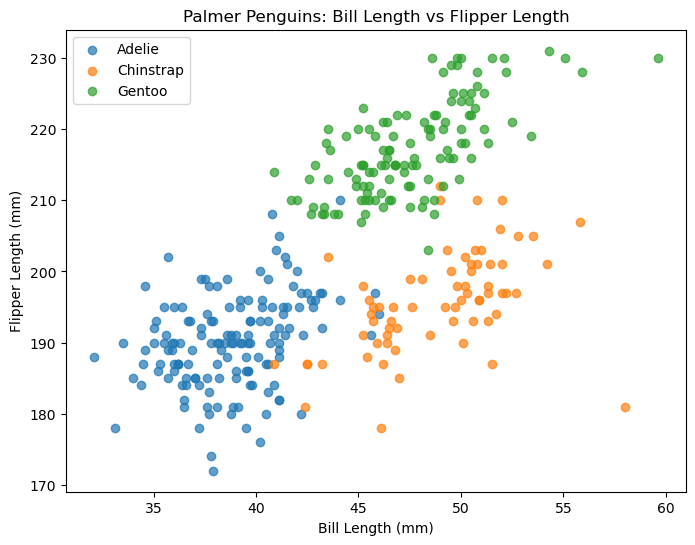

In [7]:
# Scatter plot: pick two interesting features, color by class
plt.figure(figsize=(8, 6))
for className in y.unique():
    mask = y == className
    plt.scatter(X.loc[mask, 'bill_length_mm'], X.loc[mask, 'flipper_length_mm'],
                label=className, alpha=0.7)
plt.xlabel('Bill Length (mm)')
plt.ylabel('Flipper Length (mm)')
plt.title('Palmer Penguins: Bill Length vs Flipper Length')
plt.legend()
plt.show()


## Step 6: Train/Test Split

In [8]:
# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Step 7: Build and Train the Decision Tree

Use `DecisionTreeClassifier(max_depth=3, random_state=42)` to start. We'll experiment with depth later.

In [9]:
# Create a DecisionTreeClassifier and fit it
treeModel = DecisionTreeClassifier(max_depth=3, random_state=42)
treeModel.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=3, random_state=42)

## Step 8: Evaluate

Print the accuracy and the full classification report. The report shows precision, recall, and f1-score for each class.

In [10]:
# Make predictions and print accuracy + classification report
predictions = treeModel.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f'Accuracy: {accuracy:.2%}\n')
print(classification_report(y_test, predictions))


Accuracy: 98.51%

              precision    recall  f1-score   support

      Adelie       0.97      1.00      0.98        31
   Chinstrap       1.00      0.92      0.96        13
      Gentoo       1.00      1.00      1.00        23

    accuracy                           0.99        67
   macro avg       0.99      0.97      0.98        67
weighted avg       0.99      0.99      0.98        67



## Step 9: Confusion Matrix

Show the confusion matrix as a heatmap. The diagonal shows correct predictions. Off-diagonal shows mistakes — look at WHERE the model gets confused.

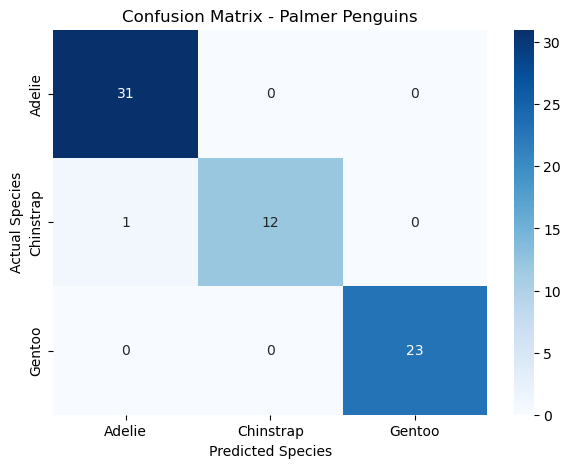

In [11]:
# Confusion matrix heatmap
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=treeModel.classes_, 
            yticklabels=treeModel.classes_)
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.title('Confusion Matrix - Palmer Penguins')
plt.show()


## Step 10: Visualize the Tree

Use `plot_tree` to see the actual decision rules. Read through it — can you follow the yes/no questions from root to leaf?

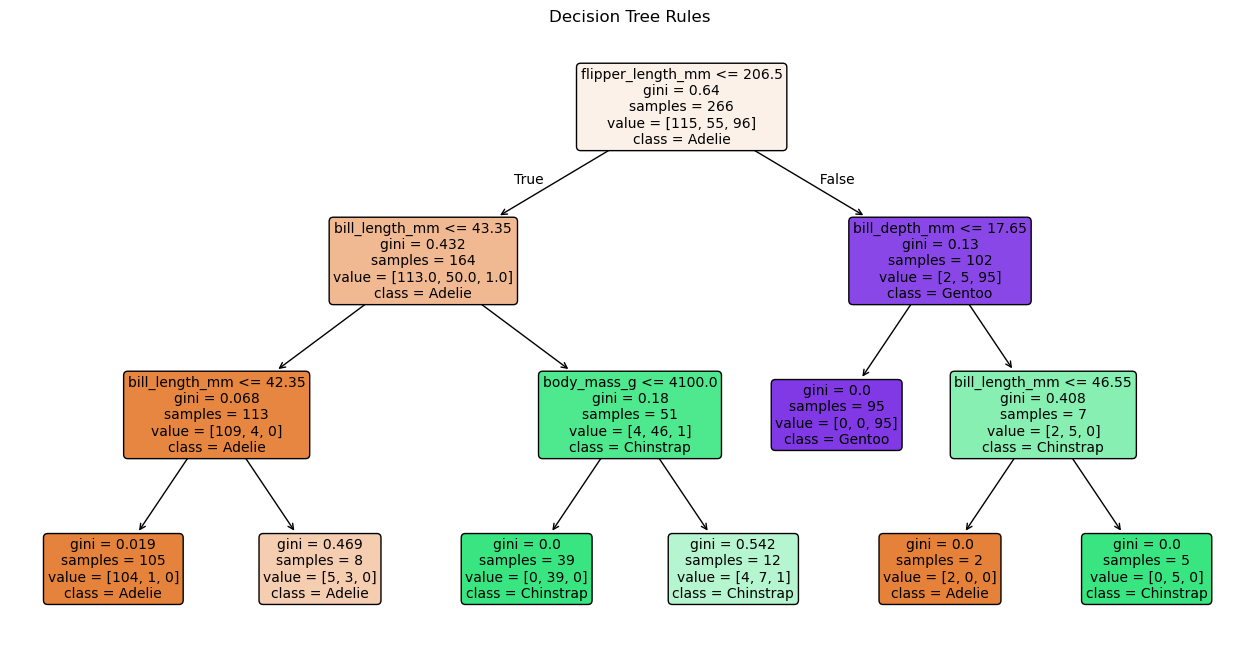

In [12]:
# Draw the decision tree
plt.figure(figsize=(16, 8))
plot_tree(treeModel, feature_names=list(X.columns), class_names=list(treeModel.classes_),
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Rules')
plt.show()


## Step 11: Feature Importance

Show which features the tree uses most. Does this match what you expected from your scatter plot?

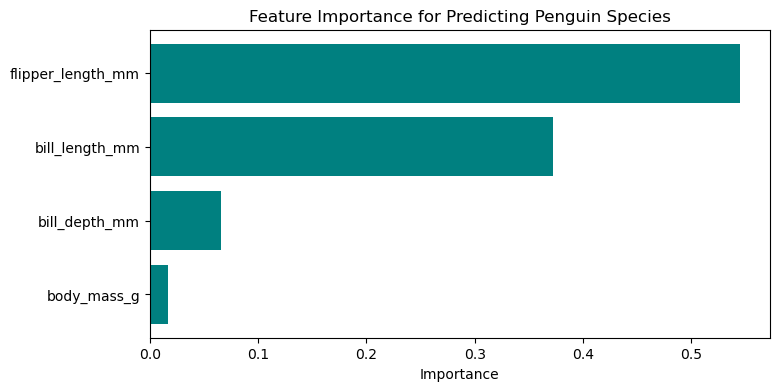

In [13]:
# Feature importance bar chart
importanceDf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': treeModel.feature_importances_
}).sort_values('Importance', ascending=True) # Ascending for horizontal bar chart

plt.figure(figsize=(8, 4))
plt.barh(importanceDf['Feature'], importanceDf['Importance'], color='teal')
plt.xlabel('Importance')
plt.title('Feature Importance for Predicting Penguin Species')
plt.show()


## Step 12: Experiment with max_depth

Try different values of `max_depth` (2, 3, 5, 10, and None for unlimited). Print the accuracy for each. What happens when the tree gets too deep? What happens when it's too shallow?

In [14]:
# Try different max_depth values and compare accuracy
print("Experimenting with max_depth:")
for depth in [2, 3, 5, 10, None]:
    m = DecisionTreeClassifier(max_depth=depth, random_state=42)
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    print(f'max_depth={depth}: accuracy={acc:.2%}')


Experimenting with max_depth:
max_depth=2: accuracy=98.51%
max_depth=3: accuracy=98.51%
max_depth=5: accuracy=100.00%
max_depth=10: accuracy=100.00%
max_depth=None: accuracy=100.00%


## Reflection (answer in this cell)

1. What dataset did you choose and why? I chose the Palmer Penguins dataset because it said it was easy. It's mostly numeric, the three species separate relatively cleanly, and it allows me to understand the classification process rather than getting stuck on data cleaning.
2. What was your accuracy? Is that good or bad for your dataset? My accuracy was 98.51%. This is good for the dataset.
3. Look at your confusion matrix — where does the model make the most mistakes? Why do you think that is? The model is almost perfect, but it might make a few mistakes distinguishing between Adelie and Chinstrap penguins. This is because Gentoo penguins are way bigger and separate easily, while Adelie and Chinstrap share more similarities in body mass and flipper length.
4. Which feature was the most important? Does that make real-world sense? Flipper length was the most important feature. This makes sense because Gentoo penguins are larger than the other two species, so a single measurement of their flipper immediately isolates them from the rest of the group. like the tiny iris.
5. What happened when you changed max_depth? Was there a "sweet spot"? At max_depth=2, the model was decent but slightly underfitting. The sweet spot was max_depth=3 or max_depth=5, where it hit peak accuracy. Going to max_depth=10 or None didn't improve the test accuracy and actually risks overfitting.
6. How does building a classification model compare to the regression model you built before? What's similar? What's different? Similarly, the overall machine learning pipeline is identical. Still clean data, split into train/test, initialize a model, .fit() it to the training data, and .predict() on the test data.
Differently, the target is a category instead of a continuous number. Because of this, the evaluation metrics are totally different; you use Accuracy and confusion matrices instead of mean squared error or r-squared.